In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import xgboost as xgb

In [137]:
data = pd.read_csv("StudentPerformanceFactors.csv")

In [138]:
data.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [139]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [140]:
data.duplicated().sum()

np.int64(0)

In [141]:
data.sort_values(by="Exam_Score", ascending=False, inplace=True)
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,7,66,High,Low,Yes,8,68,High,Yes,0,Low,Medium,Public,Negative,2,Yes,College,Moderate,Male,57
3543,14,67,Low,Low,Yes,7,66,Low,Yes,0,Low,Medium,Public,Neutral,4,No,High School,Far,Female,57
5719,9,64,Medium,Low,Yes,10,68,Low,Yes,0,Medium,Medium,Private,Negative,3,No,High School,Near,Male,57
5507,5,65,Low,High,No,7,71,Medium,Yes,0,Low,Medium,Private,Negative,2,No,College,Far,Male,56


In [142]:
ordinal_mappings = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2}
}

# Застосовуємо мапінг до всіх вказаних колонок циклом
for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)

In [143]:
binary_columns = ['Extracurricular_Activities','Internet_Access','School_Type','Learning_Disabilities','Gender']
data = pd.get_dummies(data, columns=binary_columns,drop_first=True)

In [144]:
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
1525,27,98,0,1,6,93,0,5,2,2.0,2,3,0.0,1.0,101,True,False,True,False,False
94,18,89,2,1,4,73,1,3,2,1.0,2,2,1.0,0.0,100,True,True,False,False,False
2425,23,83,2,2,4,89,0,1,1,1.0,0,3,0.0,2.0,99,True,True,True,False,True
3579,14,90,2,2,8,86,1,4,1,1.0,0,2,0.0,0.0,99,True,True,False,False,False
6347,28,96,2,0,4,98,2,1,2,2.0,2,3,0.0,0.0,98,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,7,66,2,0,8,68,2,0,0,1.0,0,2,1.0,1.0,57,True,True,True,True,True
3543,14,67,0,0,7,66,0,0,0,1.0,1,4,0.0,2.0,57,True,True,True,False,False
5719,9,64,1,0,10,68,0,0,1,1.0,0,3,0.0,0.0,57,True,True,False,False,True
5507,5,65,0,2,7,71,1,0,0,1.0,0,2,1.0,2.0,56,False,True,False,False,True


In [145]:
data.isnull().sum()

Hours_Studied                      0
Attendance                         0
Parental_Involvement               0
Access_to_Resources                0
Sleep_Hours                        0
Previous_Scores                    0
Motivation_Level                   0
Tutoring_Sessions                  0
Family_Income                      0
Teacher_Quality                   78
Peer_Influence                     0
Physical_Activity                  0
Parental_Education_Level          90
Distance_from_Home                67
Exam_Score                         0
Extracurricular_Activities_Yes     0
Internet_Access_Yes                0
School_Type_Public                 0
Learning_Disabilities_Yes          0
Gender_Male                        0
dtype: int64

In [146]:
data['Teacher_Quality'] = data['Teacher_Quality'].fillna(1)
data['Distance_from_Home'] = data['Distance_from_Home'].fillna(data['Distance_from_Home'].mean())
mode_education = data['Parental_Education_Level'].mode()[0]
data['Parental_Education_Level'] = data['Parental_Education_Level'].fillna(mode_education)

In [147]:
data.isnull().sum()

Hours_Studied                     0
Attendance                        0
Parental_Involvement              0
Access_to_Resources               0
Sleep_Hours                       0
Previous_Scores                   0
Motivation_Level                  0
Tutoring_Sessions                 0
Family_Income                     0
Teacher_Quality                   0
Peer_Influence                    0
Physical_Activity                 0
Parental_Education_Level          0
Distance_from_Home                0
Exam_Score                        0
Extracurricular_Activities_Yes    0
Internet_Access_Yes               0
School_Type_Public                0
Learning_Disabilities_Yes         0
Gender_Male                       0
dtype: int64

In [148]:
corr_data = data.corr()
corr_data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
Hours_Studied,1.000000,-0.009908,-0.016092,-0.005452,0.010977,0.024846,-0.010396,-0.014282,0.000762,-0.003903,0.009698,0.004624,-0.009199,0.012408,0.445455,-0.006017,0.005038,0.000299,-0.014401,-0.004241
Attendance,-0.009908,1.000000,-0.009313,-0.011508,-0.015918,-0.020186,-0.005010,0.014324,-0.012774,-0.000965,-0.007519,-0.022435,0.025763,-0.020163,0.581072,-0.002222,-0.018318,-0.018645,-0.022231,0.008040
Parental_Involvement,-0.016092,-0.009313,1.000000,-0.026557,-0.007945,-0.021074,-0.022393,-0.002107,0.012383,0.012953,0.021313,-0.005383,-0.007115,-0.007084,0.157114,-0.021881,0.012457,-0.016736,0.006339,-0.016133
Access_to_Resources,-0.005452,-0.011508,-0.026557,1.000000,-0.014505,0.023864,0.006206,-0.011774,-0.004210,-0.010627,-0.001247,-0.009997,-0.004955,-0.001094,0.169770,-0.008205,-0.013946,-0.020593,-0.006102,-0.000066
Sleep_Hours,0.010977,-0.015918,-0.007945,-0.014505,1.000000,-0.021750,0.001031,-0.012216,-0.018915,0.006828,-0.016867,-0.000378,0.008387,-0.002913,-0.017022,0.001379,0.011901,0.002775,0.015392,-0.007479
Previous_Scores,0.024846,-0.020186,-0.021074,0.023864,-0.021750,1.000000,0.006460,-0.013122,-0.013661,-0.003594,-0.017982,-0.011274,-0.011045,-0.006083,0.175079,0.004354,0.004304,0.013452,0.007057,0.001021
Motivation_Level,-0.010396,-0.005010,-0.022393,0.006206,0.001031,0.006460,1.000000,0.001258,0.011064,-0.012519,-0.000302,-0.007388,-0.004978,0.002317,0.086937,0.016115,0.019203,0.013754,-0.000703,0.013982
Tutoring_Sessions,-0.014282,0.014324,-0.002107,-0.011774,-0.012216,-0.013122,0.001258,1.000000,0.005083,0.001464,-0.005139,0.017733,0.004641,-0.017991,0.156525,0.003192,-0.010071,0.008257,0.007564,-0.006734
Family_Income,0.000762,-0.012774,0.012383,-0.004210,-0.018915,-0.013661,0.011064,0.005083,1.000000,-0.005147,0.016659,-0.022820,-0.000105,-0.010104,0.094555,-0.009040,0.002343,0.014794,0.016333,-0.001277
Teacher_Quality,-0.003903,-0.000965,0.012953,-0.010627,0.006828,-0.003594,-0.012519,0.001464,-0.005147,1.000000,-0.008460,-0.016044,-0.001284,0.005654,0.076684,0.017636,0.000411,-0.007581,-0.000576,-0.004968


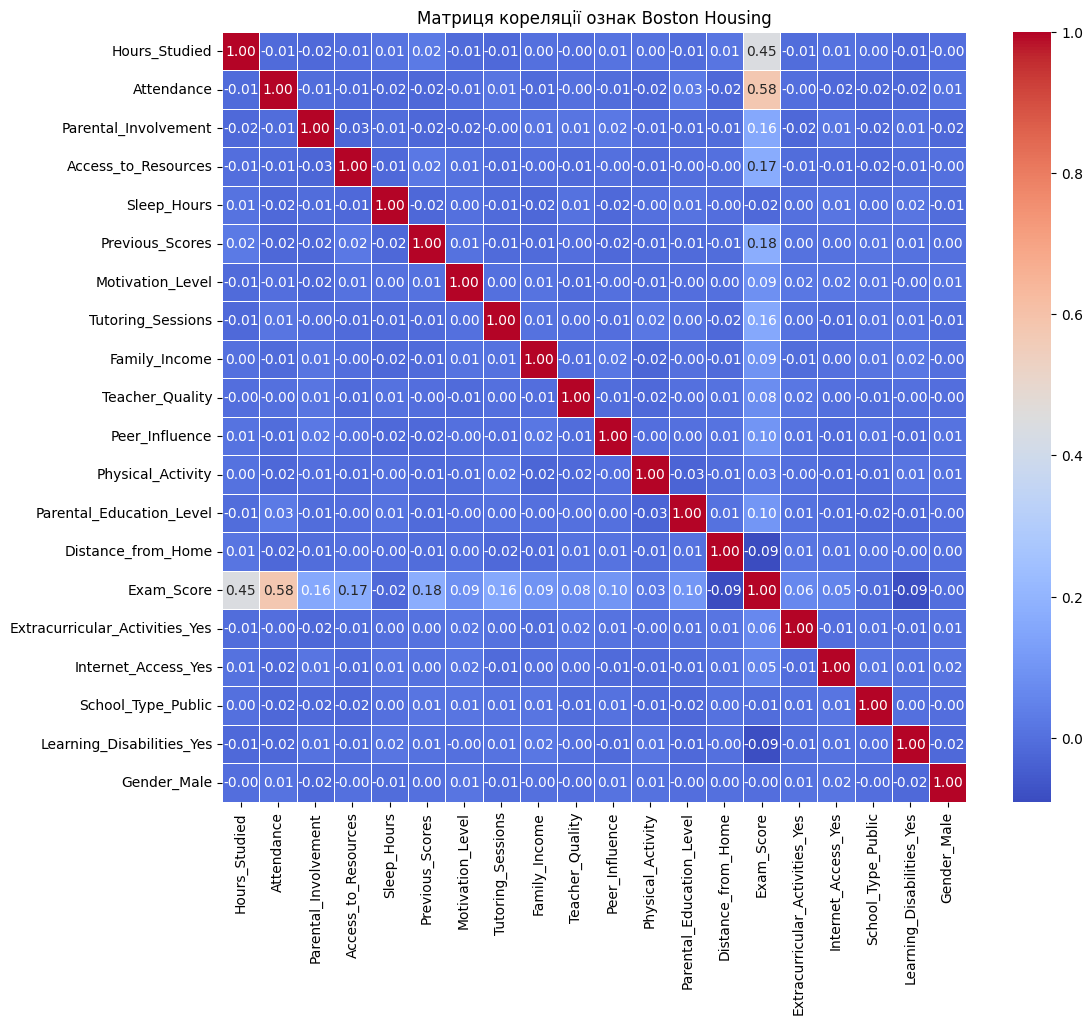

In [149]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Матриця кореляції ознак Boston Housing")
plt.show()

In [150]:
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [152]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("mean_squared_error:",mse)
print("r2:",r2)

mean_squared_error: 5.224360323251063
r2: 0.6679602754052727


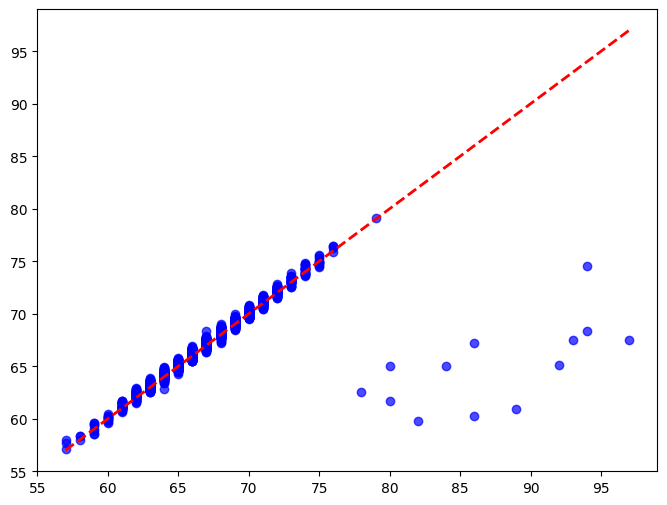

In [153]:
plt.figure(figsize=(8, 6))

plt.scatter(x=y_test, y=y_pred, alpha=0.7, color='blue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)


In [154]:
#rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model = RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_leaf=1, random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print("mean_squared_error:",rf_mse)
print("r2:",rf_r2)

mean_squared_error: 5.975263570793926
r2: 0.6202358283755045


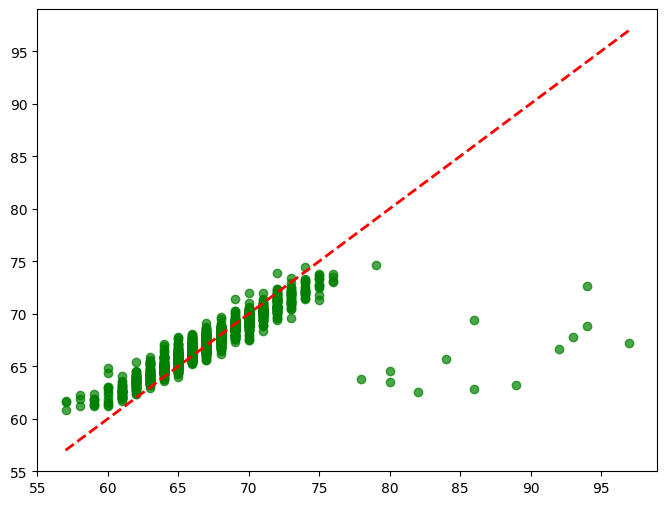

In [160]:
plt.figure(figsize=(8, 6))

plt.scatter(x=y_test, y=rf_y_pred, alpha=0.7, color='green')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

In [169]:
joblib.dump(model,'my_lr_model.pkl')
joblib.dump(rf_model,'my_rf_model.pkl')

['my_rf_model.pkl']

In [157]:
errors_df = X_test.copy()
errors_df['Actual'] = y_test
errors_df['Predicted'] = rf_y_pred
errors_df['Error'] = abs(errors_df['Actual'] - errors_df['Predicted'])

print(errors_df.sort_values(by='Error', ascending=False).head(5))

      Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
919              21          74                     2                    1   
217              19          70                     1                    0   
4779              1          88                     1                    2   
4531             26          69                     2                    2   
3124             19          90                     1                    2   

      Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
919             6               94                 1                  1   
217             7               54                 2                  0   
4779            4               72                 2                  3   
4531            7               95                 0                  0   
3124            5               90                 0                  0   

      Family_Income  Teacher_Quality  ...  Parental_Education_Level  \
919      

In [158]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)
print(f"XGBoost MSE: {xgb_mse:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")

XGBoost MSE: 5.5874
XGBoost R2: 0.6449


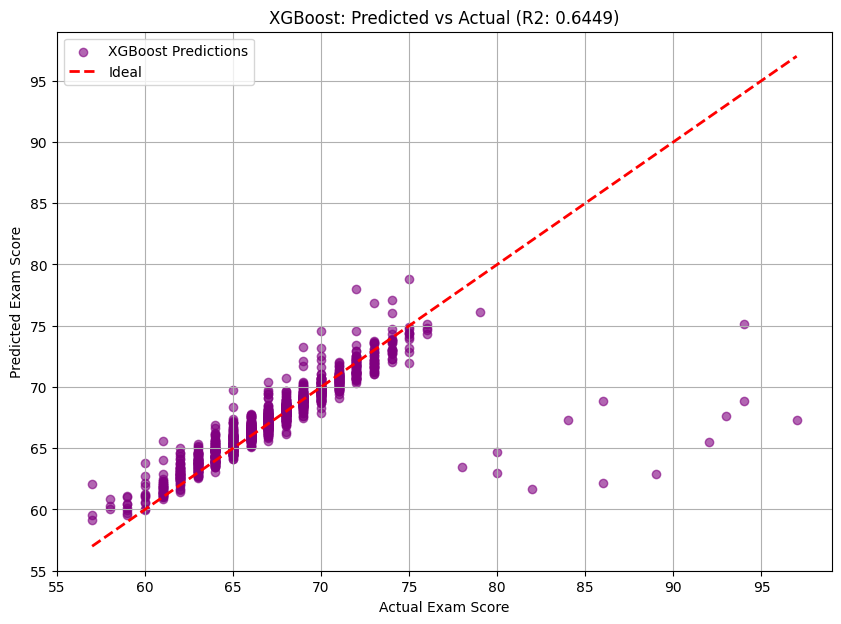

In [159]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, xgb_y_pred, alpha=0.6, color='purple', label='XGBoost Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.title(f'XGBoost: Predicted vs Actual (R2: {xgb_r2:.4f})')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.legend()
plt.grid(True)
plt.show()

In [165]:
data['Academic_Engagement'] = (data['Hours_Studied'] * data['Attendance']) / 100

data['Total_Support_Score'] = (data['Parental_Involvement'] +
                               data['Access_to_Resources'] +
                               data['Tutoring_Sessions'])

data['Motivated_Study'] = data['Hours_Studied'] * data['Motivation_Level']
data['Healthy_Balance'] = data['Sleep_Hours'] + data['Physical_Activity']

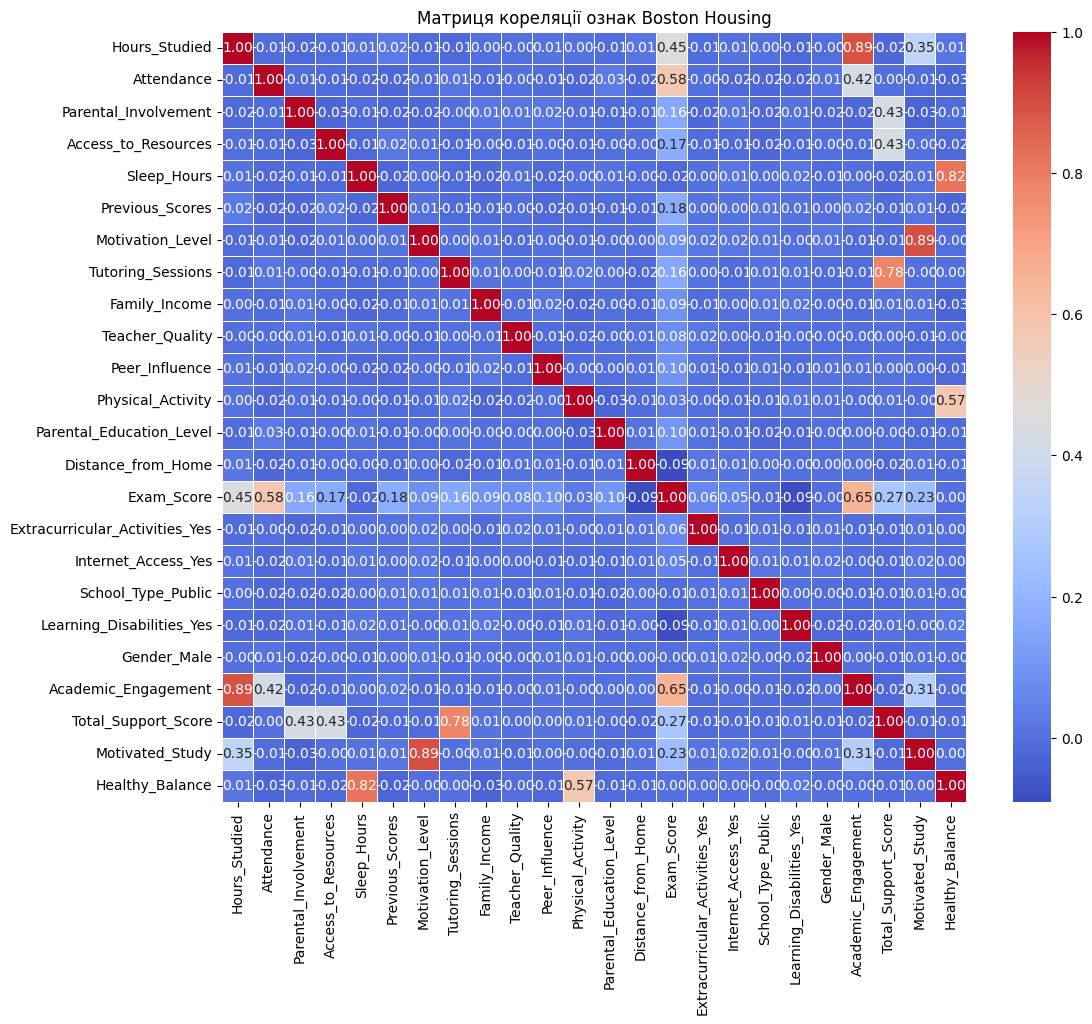

In [166]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Матриця кореляції ознак Boston Housing")
plt.show()

In [167]:
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_final = LinearRegression()
model_final.fit(X_train, y_train)

y_pred_new = model_final.predict(X_test)
print(f"New R2 Score: {r2_score(y_test, y_pred_new):.4f}")
print(f"New MSE: {mean_squared_error(y_test, y_pred_new):.4f}")

New R2 Score: 0.6686
New MSE: 5.2136
